# Visual Evaluation Notebook

This notebook is dedicated to **visual evaluation result presentation** and reads CSV files directly from `results/`.
It provides an integrated workflow for configuration-level comparison, task-level comparison, Pareto analysis, acceptance-rate analysis, speed distribution analysis, and consolidated exports.

## 1) Environment Setup

In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
project_root = cwd
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src").exists() and (candidate / "results").exists():
        project_root = candidate
        break

src_dir = str(project_root / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Results dir exists: {(project_root / 'results').exists()}")

Project root: C:\Working\speculative-decoding-main
Results dir exists: True


## 2) Load Unified Visual Evaluation Backend

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from visual_eval_backend import (
    load_visual_evaluation,
    export_summary_tables,
    export_all_figures,
    plot_speedup_by_config,
    plot_pareto_speedup_vs_disagreement,
    plot_acceptance_heatmap,
    plot_task_speedup_heatmap,
    plot_speedup_distribution,
    plot_latency_gain_vs_acceptance,
)

results_dir = project_root / 'results'
bundle = load_visual_evaluation(results_dir)

print(f'Discovered CSV files: {len(bundle.discovered_files)}')
print(f'Baseline rows: {len(bundle.baseline_df)}')
print(f'Spec rows: {len(bundle.spec_df)}')
print(f'Paired rows: {len(bundle.merged_df)}')

Discovered CSV files: 4
Baseline rows: 2000
Spec rows: 2000
Paired rows: 2000


## 3) Summary Tables

In [ ]:
if bundle.run_summary.empty:
    print('No speculative summary data found in results/.')
else:
    print('Run-level summary (sorted by speedup_mean):')
    display(bundle.run_summary)

if bundle.task_summary.empty:
    print('No task-level summary data found in results/.')
else:
    print('Task-level summary:')
    display(bundle.task_summary)

Run-level summary (sorted by speedup_mean):


,config,draft,k,regime,n_samples,n_tasks,latency_mean_s,baseline_latency_mean_s,speedup_mean,speedup_median,...,speedup_p90,ttft_mean_ms,tpot_mean_ms,tokens_per_sec_mean,baseline_tokens_per_sec_mean,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,0.5B_k4_deterministic,0.5B,4,deterministic,1000,3,27.052701,11.413919,0.432471,0.425039,...,0.533364,296.40667,218.68496,4.75524,11.02887,0.43705,1.69589,0.094,1.0,9.4
1,0.5B_k4_stochastic,0.5B,4,stochastic,1000,3,28.452806,11.649169,0.418754,0.412563,...,0.527318,304.65363,230.94874,4.51683,10.83068,0.42420,1.64312,0.831,1.0,83.1


Task-level summary:


,config,draft,k,regime,task,n_samples,speedup_mean,speedup_median,latency_mean_s,baseline_latency_mean_s,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,0.5B_k4_deterministic,0.5B,4,deterministic,cnndm,200,0.402861,0.397220,33.328589,13.147431,0.358948,1.422850,0.180000,1.0,18.000000
1,0.5B_k4_stochastic,0.5B,4,stochastic,cnndm,200,0.384353,0.386342,34.623729,13.054792,0.352985,1.400450,1.000000,1.0,100.000000
2,0.5B_k4_deterministic,0.5B,4,deterministic,gsm8k,300,0.438308,0.435586,55.953809,24.363459,0.456500,1.813233,0.150000,1.0,15.000000
3,0.5B_k4_stochastic,0.5B,4,stochastic,gsm8k,300,0.430943,0.434433,59.009568,25.092042,0.437665,1.739367,0.953333,1.0,95.333333
4,0.5B_k4_deterministic,0.5B,4,deterministic,mmlu,500,0.440813,0.426952,7.201682,2.950790,0.456620,1.734700,0.026000,1.0,2.600000
5,0.5B_k4_stochastic,0.5B,4,stochastic,mmlu,500,0.425202,0.399122,7.650379,3.021197,0.444608,1.682440,0.690000,1.0,69.000000


## 4) Core Visualizations

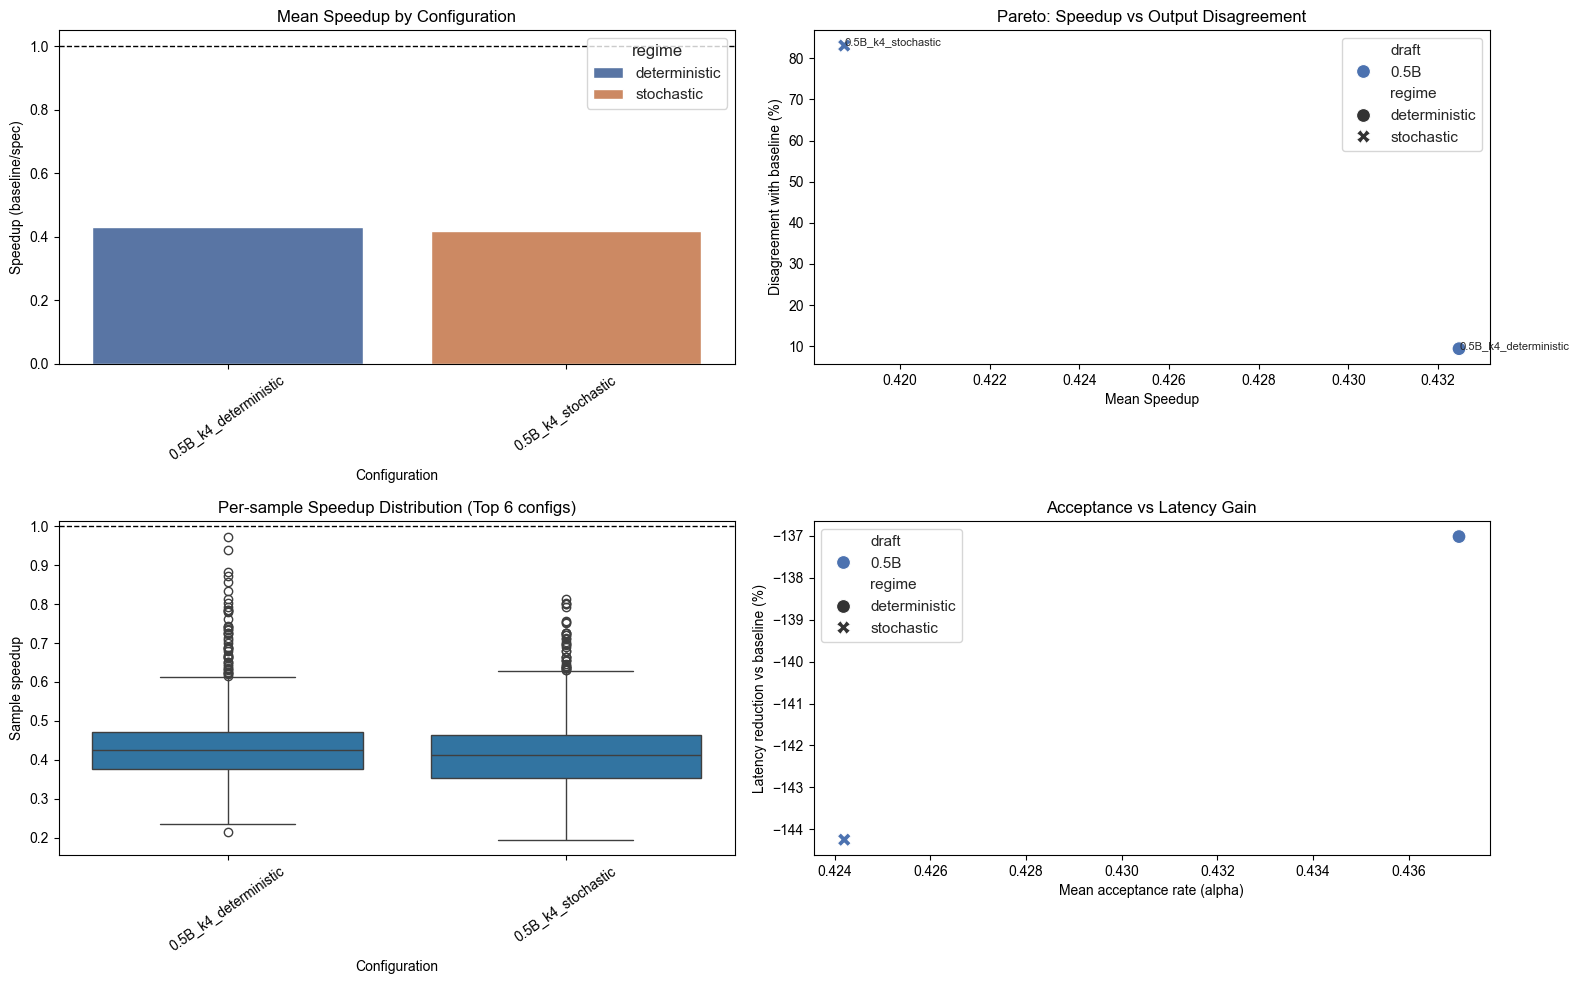

In [ ]:
if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Insufficient data for plotting. Ensure baseline_*.csv and spec_*.csv exist in results/.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plot_speedup_by_config(bundle.run_summary, ax=axes[0, 0])
    plot_pareto_speedup_vs_disagreement(bundle.run_summary, ax=axes[0, 1])
    plot_speedup_distribution(bundle.merged_df, top_configs=6, ax=axes[1, 0])
    plot_latency_gain_vs_acceptance(bundle.run_summary, ax=axes[1, 1])
    fig.tight_layout()
    plt.show()

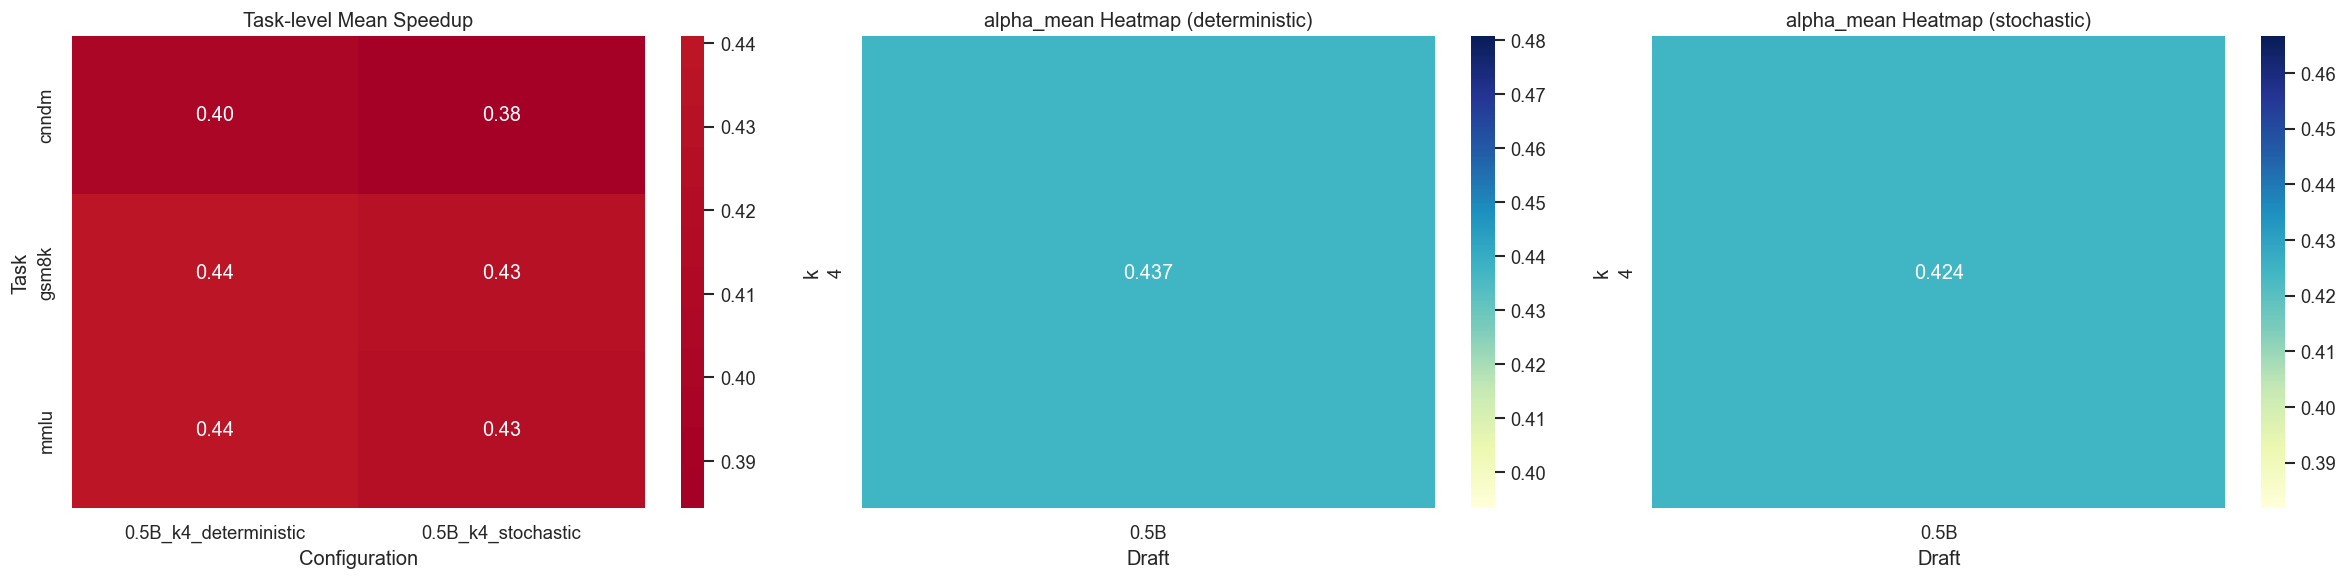

In [ ]:
if bundle.run_summary.empty or bundle.task_summary.empty:
    print('Insufficient summary data for heatmaps.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    plot_task_speedup_heatmap(bundle.task_summary, ax=axes[0])

    regimes = list(bundle.run_summary['regime'].dropna().unique())
    if 'deterministic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='deterministic', metric='alpha_mean', ax=axes[1])
    else:
        axes[1].set_axis_off()
        axes[1].set_title('No deterministic data')

    if 'stochastic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='stochastic', metric='alpha_mean', ax=axes[2])
    else:
        axes[2].set_axis_off()
        axes[2].set_title('No stochastic data')

    fig.tight_layout()
    plt.show()

## 5) Export Tables and Figures

In [ ]:
export_dir = results_dir / 'visual_eval'
export_dir.mkdir(parents=True, exist_ok=True)

table_paths = export_summary_tables(bundle, export_dir)
print('Exported tables:')
for name, p in table_paths.items():
    print(f'  {name}: {p}')

if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Skipped figure export due to missing plotting data.')
else:
    fig_paths = export_all_figures(bundle, export_dir)
    print('Exported figures:')
    for name, p in fig_paths.items():
        print(f'  {name}: {p}')

Exported tables:
  run_summary: C:\Working\speculative-decoding-main\results\visual_eval\run_summary.csv
  task_summary: C:\Working\speculative-decoding-main\results\visual_eval\task_summary.csv
  pairwise_sample_metrics: C:\Working\speculative-decoding-main\results\visual_eval\pairwise_sample_metrics.csv
Exported figures:
  speedup_by_config: C:\Working\speculative-decoding-main\results\visual_eval\speedup_by_config.png
  pareto_speedup_vs_disagreement: C:\Working\speculative-decoding-main\results\visual_eval\pareto_speedup_vs_disagreement.png
  acceptance_heatmaps: C:\Working\speculative-decoding-main\results\visual_eval\acceptance_heatmaps.png
  task_speedup_heatmap: C:\Working\speculative-decoding-main\results\visual_eval\task_speedup_heatmap.png
  speedup_distribution: C:\Working\speculative-decoding-main\results\visual_eval\speedup_distribution.png
  latency_gain_vs_acceptance: C:\Working\speculative-decoding-main\results\visual_eval\latency_gain_vs_acceptance.png


## 6) Quick Interpretation Helper

Recommended reading order:
1. Check `speedup_mean` and `disagreement_rate_pct` in `run_summary`.
2. In the Pareto chart, identify configurations with high speedup and low disagreement.
3. In the task heatmap, check for task-level regressions (for example, unstable speedup on specific tasks).